# How Do Algorithms Read and Reduce Emotion?



## Purpose of Analysis
We investigated how modern NLP models interpret and reduce emotional expression in text, asking: **How do algorithms read and reduce emotion?**

To explore this, we conducted a series of behavioral tests and visual analyses using the GoEmotions dataset of Reddit comments annotated with 27+1 fine-grained emotions. We examined how two models, GPT-4 (zero-shot) and BERT (Savani), compare to human-labeled ground truth (GoEmotions dataset).

**BERT (Savani)** is a fine-tuned version of BERT-base trained on the GoEmotions dataset. It represents a supervised approach where the model learns directly from human emotion annotations. We chose it to evaluate how well a specialized, task-specific model aligns with ground truth.

**GPT-4**, in contrast, is a large, general-purpose language model. We used it in zero-shot mode, without any fine-tuning—to test whether a highly capable, general model can intuitively recognize emotional nuance without direct supervision.

**These models represent two ends of the spectrum**: one trained explicitly on emotion data, and the other relying on broad linguistic knowledge and reasoning. Comparing them helps us understand the trade-offs between supervised task alignment and emergent generalization.

**Well, what about TextBlob or NRC Lexicons?**
These models differ significantly from traditional tools like **TextBlob** and **NRC lexicons**, which are rule-based or dictionary-based approaches. TextBlob performs basic sentiment analysis, labeling text as positive, negative, or neutral, without access to the 28 fine-grained GoEmotions categories. NRC assigns emotions based on static word lists, ignoring context, negation, sarcasm, and polysemy.

**And, what does "fine-tuning a model" mean?**
In our case, the BERT model was first trained on general English text (like Wikipedia), but then it was fine-tuned, given specific training, on the GoEmotions dataset. That means it was shown many Reddit comments with human-labeled emotion tags and learned to predict those specific emotion categories.


<br>

Our analyses included:

  * **Topic Modeling & Emotion Linkage** to explore how latent themes relate to emotional patterns.

  * **Model Disagreement Sampling**, analyzing how **GPT-4** and **BERT** interpret the same emotionally annotated comments, revealing divergence and reduction.

  * **Confusion Matrices** to visualize where and how models misclassify emotions.

  * **Alluvial Flow Charts** to trace emotion shifts across models: from human annotation → BERT → GPT-4.

  * **Label Entropy** to measure how confident or uncertain models are in their emotional assignments.

<br>

Together, these analyses uncover where algorithms flatten emotional nuance, revealing systematic tendencies to simplify, reinterpret, or erase complex affective meaning in text.

### Load the GoEmotions Dataset

In [75]:
!pip install -U gdown==4.6.0
!pip install --upgrade openai
!pip install transformers torch
!pip install contractions

In [76]:
!gdown --folder --fuzzy https://drive.google.com/drive/folders/1vGj80lLjIkk6V6lXMG3JM51H-bKbQcZn --remaining-ok

Retrieving folder list
Processing file 1MS7xYU8bB71UyGwf5m5KxSIy1YiEY-pq README.md
Retrieving folder 1U7kHCZkDKSHMXueTee5oW2K7PVVDj64x data
Retrieving folder 10kd3UCbDTKudmt77Bf2lB7BOXRePPGeV full_dataset
Processing file 11YDFat3U0K0r5IEPOI078Wc46R4BxAxZ goemotions_1.csv
Processing file 1tW_i58QizFD140i4cF_wesdlsW9By0eU goemotions_2.csv
Processing file 1LFTAvp7bgdXlfEvLRwkIpn5JjaN-xGxf goemotions_3.csv
Processing file 1CgIlbCAkZMF4-FKN2zlkI-cGjFfkW2vTnqHg0KtoKpU goemotions_2
Processing file 1lUBYRdLK07-O6S-QyisWx0RT27rSwjc-atWdz7MTTPg goemotions_1
Processing file 1T8L75jScDUCXOoNRwyJl7R0VCRVjkiJibbUHOQ6LDkU goemotions_3
Processing file 1NFmsk5UH1MpdReUixiln8xCJItFhRMBP Group 7 - Short Paper 
Processing file 13P5YcA99x_JEml1j0C9NAfBT3_XPIHyzw7Ay9YCNrFM Group 7 How Do Algorithms Read and Reduce Emotion?
Retrieving folder list completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1MS7xYU8bB71UyGwf5m5KxSIy1YiEY-pq



## **Dataset Summary**

The GoEmotions dataset contains 58k carefully curated Reddit comments from 2005 - 2019, labeled for 27 emotion categories or Neutral. This dataset is intended for **multi-class, multi-label emotion classification**.

**Languages**: English

## **Dataset Structure**

### **Data Instances**

Each instance is a reddit comment with a corresponding ID and one or more emotion annotations (or neutral).

### **Data Fields**

* `text`: the reddit comment
* `labels`: the emotion annotations
* `comment_id`: unique identifier of the comment (can be used to look up the entry in the raw dataset)

* `author`: The Reddit username of the comment's author.
* `subreddit`: The subreddit that the comment belongs to.
* `link_id`: The link id of the comment.
* `parent_id`: The parent id of the comment.
* `created_utc`: The timestamp of the comment.
* `rater_id`: The unique id of the annotator.
* `example_very_unclear`: Whether the annotator marked the example as being very unclear or difficult to label (in this case they did not choose any emotion labels).

**If we're just exploring the dataset:**

* Use any one file (typically `goemotions_1.csv` is enough — it's the training set and has a representative distribution).


**If we're planning evaluate an already trained model:**

* Use the test dataset: `goemotions_3.csv`


**If we're planning to train and evaluate a model:**

Use all three like this:

* Train your model on `goemotions_1.csv`
* Tune hyperparameters on `goemotions_2.csv`
* Evaluate performance on `goemotions_3.csv`


**If we want a full analysis of the entire dataset:**

*   Use all three and concatenate them: `goemotions_1.csv`, `goemotions_2.csv`, `goemotions_3.csv`


In [77]:
import pandas as pd
import ast

train_data_path = '/content/ReadAndReduceEmotions/data/full_dataset/goemotions_1.csv'
validate_data_path = '/content/ReadAndReduceEmotions/data/full_dataset/goemotions_2.csv'
test_data_path = '/content/ReadAndReduceEmotions/data/full_dataset/goemotions_3.csv'

train_df = pd.read_csv(train_data_path)
val_df = pd.read_csv(validate_data_path)
test_df = pd.read_csv(test_data_path)

full_dataset_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Combined dataset shape: {full_dataset_df.shape}")
test_df.head(10)

Combined dataset shape: (211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,Worst ending ever! I won't spoil it but this one sucked worse than the avengers last movie!,eee021b,tribaltrak,movies,t3_agxbsx,t3_agxbsx,1.547847e+09,42,False,0,...,0,0,0,0,0,0,0,0,0,0
1,Happy cake day u/sneakpeekbot!,ed00f1z,InfernicFuse,danganronpa,t3_abajdo,t1_eczoocj,1.546328e+09,24,False,0,...,0,0,0,0,0,0,0,0,0,0
2,Was he rejected because of his methodology or because of the content of his studies?,ee1h5v1,OssToYouGoodSir,medicine,t3_aflo7s,t1_ee0v0vv,1.547464e+09,77,False,0,...,0,0,0,0,0,0,0,0,0,0
3,"thanks, I agree",eemi935,PMOFreeForever,NoFap,t3_ai7h09,t1_eelu54r,1.548088e+09,46,False,0,...,0,0,0,0,0,0,0,0,0,0
4,Why would you doubt it dumbass?,eduun99,ugliestman1,Tinder,t3_aejwne,t1_edumeal,1.547255e+09,36,False,0,...,0,0,0,0,0,0,0,0,0,0
5,Just take them and get them vaccinated without his knowledge. Only one parent is needed. Dont even tell him after it's done.,eexcq19,Barnesatron,relationship_advice,t3_ajmn30,t3_ajmn30,1.548424e+09,12,False,0,...,0,0,0,0,0,0,0,0,0,1
6,[NAME] is a hungry little bastard.,ef9y4uz,Kozlow,nyjets,t3_al1xzf,t3_al1xzf,1.548782e+09,27,False,0,...,0,0,0,0,0,0,0,0,0,0
7,If only someone would love the septuple-PhD in the galaxy for her mind.lol,eediukq,[deleted],masseffect,t3_ah9xnb,t3_ah9xnb,1.547837e+09,26,False,0,...,0,0,0,0,0,0,0,0,0,0
8,"The street drugs here are laced with fentanyl, i think I’ll do something else",edy3oex,Incorrect_name,furry_irl,t3_afcr1b,t1_edy32t9,1.547349e+09,15,False,0,...,0,0,0,0,0,0,0,0,0,0
9,Both parents were drunk. Where were the small children? You helped her cheat and possibly contribute to child neglect. Awesome.,edsxhhe,HopefulHat8,confession,t3_aeq2xw,t3_aeq2xw,1.547213e+09,51,False,0,...,0,0,0,0,0,0,0,1,0,0


### **27+1 Emotion Label Categories**

GoEmotions taxonomy: Includes 28 emotion categories, including “neutral”.


---


![GoEmotions](https://blogger.googleusercontent.com/img/a/AVvXsEigu_MmQ7zbqciHaEAl_rjZYNEPX6GyGEh9nkIoGOaMUg3BPCizBGJc-FhAMluHZHVX2cArth_0RgQVaEELUT3Y4oWv3V1h_ES5YjNxXJPre5YZy_2bG7ihLKjKOrQJTjEM-9SFLTFq6-Beo94ZS7yqslE-VFOH4xRlUX35rBVYtPskYGIv4DbBRiL08Q=s16000)



In [78]:
from IPython.display import display

non_emotion_cols = {
    'text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
    'created_utc', 'rater_id', 'example_very_unclear', 'decoded_labels'
}

emotion_columns = [col for col in test_df.columns if col not in non_emotion_cols]

print("Emotion Categories (27 fine-grained + 1 neutral):\n")
for i, emotion in enumerate(emotion_columns, 1):
    print(f"{i:2}. {emotion}")

Emotion Categories (27 fine-grained + 1 neutral):

 1. admiration
 2. amusement
 3. anger
 4. annoyance
 5. approval
 6. caring
 7. confusion
 8. curiosity
 9. desire
10. disappointment
11. disapproval
12. disgust
13. embarrassment
14. excitement
15. fear
16. gratitude
17. grief
18. joy
19. love
20. nervousness
21. optimism
22. pride
23. realization
24. relief
25. remorse
26. sadness
27. surprise
28. neutral


![GoEmotions](https://blogger.googleusercontent.com/img/a/AVvXsEgVywDXEAkdsfhGlIyysLZ1_YowBiIPUnzWjNEo8-ySop1zj3j60PkRlrfyDcR1ayMs_A4SF10zupbLtyYVkgQgMz9H21paeVnDUqOKa2mgo8LKpHvpBKF3Tn1YD8ZF3Rr2Z9NYhNj9LNoVDMwB2im_xdZrffHIJtStEsbfJuxbsGz_XPuY_X9WXGVqTw=s16000)

 Emotions are not distributed uniformly in the GoEmotions dataset. The **high frequency of positive emotions** reinforces GoEmotions motivation for a more diverse emotion taxonomy than that offered by the usual six basic emotions.

**Paul Ekman’s theory of universal emotions**

1. Anger
2. Disgust
3. Fear
4. Happiness
5. Sadness
6. Surprise

### **Example Reddit Posts from Test Dataset with the Emotion Categories**

---



In [79]:
  def get_example_posts_by_emotion(df, emotion_columns):
    examples = []
    for emotion in emotion_columns:
        # Filter rows where this emotion == 1 (can be multi-label)
        filtered = df[df[emotion] == 1]

        if not filtered.empty:
            row = filtered.iloc[0]
            # Get all emotions assigned in this annotation
            all_labels = [e for e in emotion_columns if row[e] == 1]
            examples.append((emotion, all_labels, row['text']))
        else:
            examples.append((emotion, [], "[No example found]"))

    return pd.DataFrame(examples, columns=['Target Emotion', 'All Assigned Labels', 'Example Reddit Post'])


# Build the DataFrame
test_example_df = get_example_posts_by_emotion(test_df, emotion_columns)

# Reset index to start from 1
test_example_df.index = test_example_df.index + 1
test_example_df.index.name = "#"

# Display with full post content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

display(test_example_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-family': 'monospace'
}))

,Target Emotion,All Assigned Labels,Example Reddit Post
#,,,
1,admiration,"['admiration', 'approval']",You are correct. But sometimes you might have a plan or you have to improvise. I’m glad it worked.
2,amusement,['amusement'],If only someone would love the septuple-PhD in the galaxy for her mind.lol
3,anger,"['anger', 'disgust']",Why would you doubt it dumbass?
4,annoyance,['annoyance'],"yeah [NAME] can eat glass, that guy fuckin sucks"
5,approval,"['approval', 'gratitude']","thanks, I agree"
6,caring,['caring'],Nukeville sounds like a nicer neighborhood. Like no broken and burnt houses and like children playing in the street and people having barbecues
7,confusion,['confusion'],Was he rejected because of his methodology or because of the content of his studies?
8,curiosity,['curiosity'],How about a downvote for the update?
9,desire,['desire'],[NAME] I wish you *were* silent


### **Filter only comments with multi-label emotions classified**:

In [80]:
# Filter only rows where >1 emotion label is assigned
multi_label_df = test_df[test_df[emotion_columns].sum(axis=1) > 1].copy()

# Create table
def get_multilabel_examples(df, emotion_cols, num_examples=15):
    examples = []
    for _, row in df.iterrows():
        labels = [emotion for emotion in emotion_cols if row[emotion] == 1]
        if len(labels) > 1:  # Ensure it's still multi-label (extra check)
            text = row['text']
            examples.append((labels, text))
    return pd.DataFrame(examples[:num_examples], columns=['All Assigned Labels', 'Example Reddit Post'])

# Build and display table
multilabel_example_df = get_multilabel_examples(multi_label_df, emotion_columns)

# Display nicely
pd.set_option('display.max_colwidth', None)
display(multilabel_example_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-family': 'monospace'
}))

,All Assigned Labels,Example Reddit Post
0,"['approval', 'gratitude']","thanks, I agree"
1,"['anger', 'disgust']",Why would you doubt it dumbass?
2,"['admiration', 'approval']",You are correct. But sometimes you might have a plan or you have to improvise. I’m glad it worked.
3,"['excitement', 'love']",*Hey just noticed..* it's your **8th Cakeday** [NAME]! ^(hug)
4,"['admiration', 'disappointment']","Then he should have had his head up. This is hockey, not figure skating. Great hit! I miss that kind of contact in the game."
5,"['curiosity', 'sadness']","Sorry what, seriously? Who decided that shit, that wasn't even [NAME]?"
6,"['curiosity', 'grief']",If I died I've always wondered who will be at my funeral. I imagine only my mom. Maybe one of these days I'll find out.
7,"['admiration', 'gratitude']",Super helpful. Thanks!
8,"['admiration', 'approval']","If it’s a one hit kill like the regular crossbow, absolutely would be a fantastic crate weapon."
9,"['disappointment', 'embarrassment']","They are children, they have no souls."


### **Filter only comments with a single emotion classfied**:

In [81]:
single_emotion_df = test_df[test_df[emotion_columns].sum(axis=1) == 1].copy()
single_emotion_df.head(10)

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,Worst ending ever! I won't spoil it but this one sucked worse than the avengers last movie!,eee021b,tribaltrak,movies,t3_agxbsx,t3_agxbsx,1.547847e+09,42,False,0,...,0,0,0,0,0,0,0,0,0,0
1,Happy cake day u/sneakpeekbot!,ed00f1z,InfernicFuse,danganronpa,t3_abajdo,t1_eczoocj,1.546328e+09,24,False,0,...,0,0,0,0,0,0,0,0,0,0
2,Was he rejected because of his methodology or because of the content of his studies?,ee1h5v1,OssToYouGoodSir,medicine,t3_aflo7s,t1_ee0v0vv,1.547464e+09,77,False,0,...,0,0,0,0,0,0,0,0,0,0
5,Just take them and get them vaccinated without his knowledge. Only one parent is needed. Dont even tell him after it's done.,eexcq19,Barnesatron,relationship_advice,t3_ajmn30,t3_ajmn30,1.548424e+09,12,False,0,...,0,0,0,0,0,0,0,0,0,1
6,[NAME] is a hungry little bastard.,ef9y4uz,Kozlow,nyjets,t3_al1xzf,t3_al1xzf,1.548782e+09,27,False,0,...,0,0,0,0,0,0,0,0,0,0
7,If only someone would love the septuple-PhD in the galaxy for her mind.lol,eediukq,[deleted],masseffect,t3_ah9xnb,t3_ah9xnb,1.547837e+09,26,False,0,...,0,0,0,0,0,0,0,0,0,0
8,"The street drugs here are laced with fentanyl, i think I’ll do something else",edy3oex,Incorrect_name,furry_irl,t3_afcr1b,t1_edy32t9,1.547349e+09,15,False,0,...,0,0,0,0,0,0,0,0,0,0
9,Both parents were drunk. Where were the small children? You helped her cheat and possibly contribute to child neglect. Awesome.,edsxhhe,HopefulHat8,confession,t3_aeq2xw,t3_aeq2xw,1.547213e+09,51,False,0,...,0,0,0,0,0,0,0,1,0,0
10,How about a downvote for the update?,ef9q28z,H010CR0N,entitledparents,t3_al0vqd,t1_ef9nein,1.548777e+09,3,False,0,...,0,0,0,0,0,0,0,0,0,0
11,"yeah [NAME] can eat glass, that guy fuckin sucks",eenftjo,lady_taffingham,popheads,t3_aic96m,t1_eemxzk3,1.548111e+09,8,False,0,...,0,0,0,0,0,0,0,0,0,0



### **Single vs. Multi vs. Unclear Proportions**
Visualize the proportion of test comments that are single-label, multi-label, or marked `very_unclear = TRUE`.

**Single-Label**: comments where annotators agreed on one dominant emotion. These are the clearest, most emotionally consistent texts in the dataset — for example, a comment might be labeled ***gratitude*** and nothing else.

**Multi-label**: comments where annotators labeled with more than one emotion. These reflect the complexity of human affect, where a single comment might express mixed or layered emotions, like both ***joy*** and ***pride***, or ***disappointment*** and ***anger***.

**Very Unclear**: comments where annotators found the text too ambiguous or devoid of a clear emotional signal, and thus assigned no emotion or neutral label. This category highlights portions of the dataset where **emotion classification was not possible**.


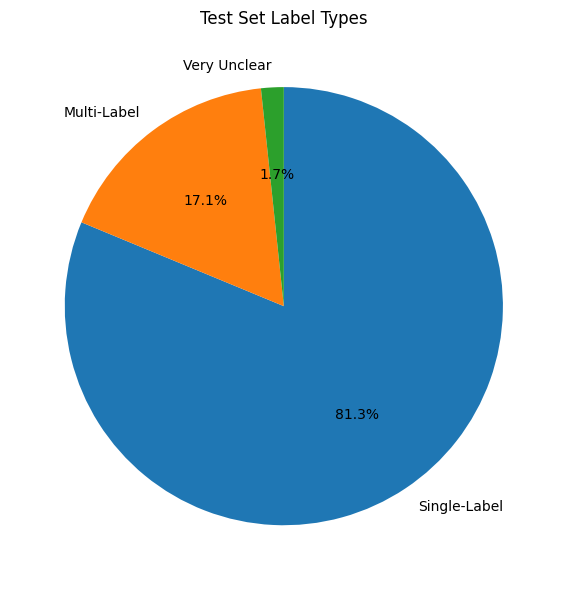

In [82]:
import matplotlib.pyplot as plt

# Compute counts on test set
# Using existing variable names: 'test' contains the test DataFrame
single_count = single_emotion_df.shape[0]
multi_count = test_df[test_df[emotion_columns].sum(axis=1) > 1].shape[0]
unclear_count = test_df['example_very_unclear'].sum()

# Pie chart
from pandas import Series
df_counts = Series({
    'Single-Label': single_count,
    'Multi-Label': multi_count,
    'Very Unclear': unclear_count
})
plt.figure(figsize=(6,6))
df_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, counterclock=False)
plt.ylabel('')
plt.title('Test Set Label Types')
plt.tight_layout()
plt.show()

### **Example of One Comment with Different Emotions Classified Annotated by Different Raters**

In [83]:
def get_single_emotion(row):
    emotions = [emotion for emotion in emotion_columns if row[emotion] == 1]
    return emotions[0] if len(emotions) == 1 else emotions

# Filter for the target comment
example_id = 'ed3uqb6'
subset = test_df[test_df['id'] == example_id].copy()

# Add column showing only the emotion(s) assigned by each rater
subset['selected_emotion'] = subset.apply(get_single_emotion, axis=1)

# Display relevant info: text, rater_id, and selected emotion
subset[['text', 'rater_id', 'selected_emotion']]

,text,rater_id,selected_emotion
28641,"I think this discussion would benefit from differentiating between ""acceptance"" and ""normalization""",7,realization
52144,"I think this discussion would benefit from differentiating between ""acceptance"" and ""normalization""",36,neutral
64706,"I think this discussion would benefit from differentiating between ""acceptance"" and ""normalization""",61,optimism
67028,"I think this discussion would benefit from differentiating between ""acceptance"" and ""normalization""",4,approval


### **Examples of 10 Comments with Annotations by Different Raters**

In [84]:
# Ensure selected_emotion column is set
single_emotion_df['selected_emotion'] = single_emotion_df.apply(get_single_emotion, axis=1)

# Identify texts with label disagreements
label_counts = single_emotion_df.groupby('text')['selected_emotion'].nunique().reset_index()
label_counts = label_counts[label_counts['selected_emotion'] > 1]

# Filter rows with disagreement
disagreement_rows = single_emotion_df[single_emotion_df['text'].isin(label_counts['text'])]


# Format annotations: rater_id + emotion (unclear flag optional)
def format_annotation(row):
    return f"rater {row['rater_id']}: {row['selected_emotion']}"

# Add a formatted column
disagreement_rows.loc[:, 'formatted'] = disagreement_rows.apply(format_annotation, axis=1)

# Group by text and aggregate annotations
grouped = disagreement_rows.groupby('text')['formatted'].apply(list).reset_index(name='annotations')

# annotations as one string
grouped['annotations'] = grouped['annotations'].apply(lambda x: "; ".join(x))

# Display
grouped.head(10)

/tmp/ipython-input-84-2655324861.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,text,annotations
0,">sexuality shouldn’t be a grouping category It makes you different from othet ppl so imo it fits the definition of ""grouping""",rater 36: disapproval; rater 27: neutral
1,"I think this discussion would benefit from differentiating between ""acceptance"" and ""normalization""",rater 7: realization; rater 36: neutral; rater 61: optimism; rater 4: approval
2,"Luckily from him, there is no death penalty in Brazil and the maximum a person can serve in a Brazilian jail is 20 consecutive years.",rater 16: neutral; rater 51: relief
3,"No mention of [NAME]? For shame, subreddit. For shame.",rater 76: curiosity; rater 20: confusion
4,"Turkey's situation is bad, but still nothing compared to Venezuela.",rater 52: anger; rater 16: neutral; rater 51: sadness
5,"anyone who hasn't seen this, it's unbelievably bad.",rater 51: sadness; rater 41: disapproval
6,"cute, new driver still cares. Come back in 4 months and u will be showing pictures of that bag thrown on the trunk.",rater 55: realization; rater 60: annoyance
7,"so just throwing this out there, you can have conversations and arguments without being an ass.",rater 4: anger; rater 11: disgust; rater 55: annoyance
8,"""*You can sifu stance your bitchass on outta here!""*",rater 19: annoyance; rater 76: approval
9,"""*[NAME], what's your favourite 80s band?*"" ""*New ORDERRRR!*""",rater 36: curiosity; rater 2: curiosity; rater 20: confusion; rater 57: neutral


## **Topic Modeling & Emotion Linkage**
This section fits an LDA model to single-emotion comments
and cross-tabulates dominant topics vs. emotion labels.

An **LDA (Latent Dirichlet Allocation)** model is a generative topic modeling algorithm. It's used to automatically discover the hidden thematic structure (topics) in a large collection of texts, without requiring labeled data.

In [85]:
import re
import nltk
import contractions
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Ensure stopwords are downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


theme_names = [
    'Social Judgement',       # bad, feel, better, just, looks, way, makes, guy, sounds
    'Personal Reflection',    # introspective language
    'Positive Feedback',      # praise, thanks, love
    'Negative Emotion',       # anger, hate, sad words
    'Humorous Reaction',      # jokes, laughter indicators
    'Inquisitive Tone',       # questions, curiosity
    'Gratitude & Appreciation',
    'Neutral Commentary'
]

# Clean the text
def clean_text(text):
    text = contractions.fix(text)                         # Expand contractions
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # Remove punctuation/numbers
    text = text.lower()                                   # Lowercase
    return text

# Apply cleaning
texts = single_emotion_df['text'].tolist()
texts_cleaned = [clean_text(t) for t in texts]

# Vectorize with real stopword removal
vectorizer = CountVectorizer(max_features=2000, stop_words=list(stop_words))
doc_term = vectorizer.fit_transform(texts_cleaned)

# Fit LDA
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_topics = lda.fit_transform(doc_term)

# Show top words per topic
terms = vectorizer.get_feature_names_out()
for idx, comp in enumerate(lda.components_):
    top_indices = comp.argsort()[-10:][::-1]
    top_words = [terms[i] for i in top_indices]
    print(f"{theme_names[idx]}: {', '.join(top_words)}")

# Assign dominant topic and label with theme name
single_emotion_df['dominant_topic'] = lda_topics.argmax(axis=1)

# Crosstab and rename index
topic_emotion_ct = pd.crosstab(single_emotion_df['dominant_topic'], single_emotion_df['selected_emotion'])
topic_emotion_ct.index = theme_names

print(topic_emotion_ct)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Social Judgement: us, would, best, ever, day, happy, read, let, seen, one
Personal Reflection: name, good, oh, know, cannot, one, bad, guy, believe, see
Positive Feedback: would, thank, people, got, great, thought, make, though, wrong, something
Negative Emotion: get, really, going, much, way, sure, well, time, maybe, see
Humorous Reaction: like, man, lol, looks, years, look, get, right, sounds, feel
Inquisitive Tone: go, need, sorry, mean, would, want, yes, people, fuck, please
Gratitude & Appreciation: love, thanks, know, never, people, damn, hate, lot, much, last
Neutral Commentary: name, even, year, still, think, point, new, love, one, way
selected_emotion          admiration  amusement  anger  annoyance  approval  \
Social Judgement                 567        190    264        376       564   
Personal Reflection              511        185    157        349       419   
Positive Feedback                680        270    167        340       455   
Negative Emotion                

**How come "*name*" is in both Neutral Commentary and Personal Reflection?**


LDA assigns each word a probability of belonging to each topic. A word like "***name***" might co-occur with introspective language (→ Personal Reflection) and with factual or narrative sentences (→ Neutral Commentary).

**Example**:

* **Personal Reflection**: “I don’t like my name” → reflective, identity-oriented.

* **Neutral Commentary**: “That’s just his name” → factual, observational.

### **Word Clouds for Each Topic**

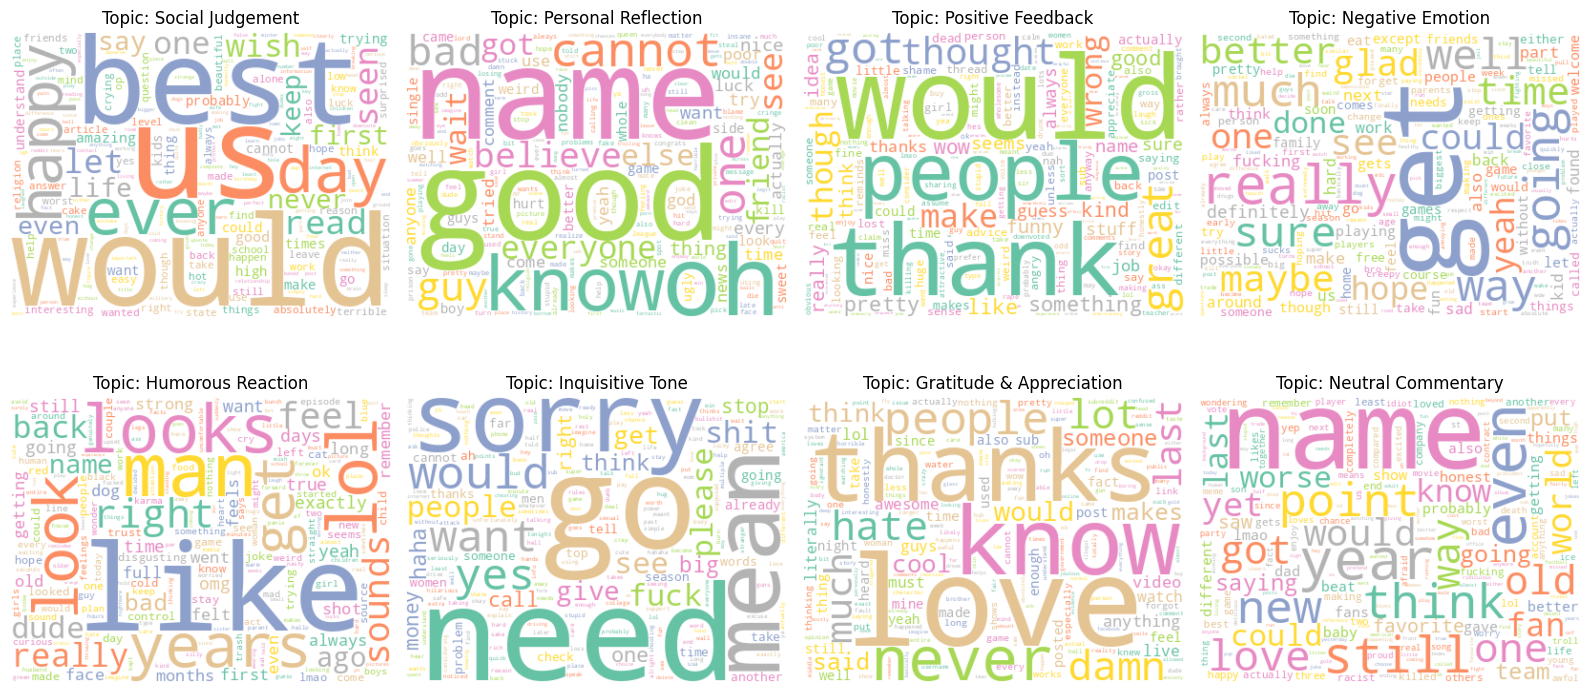

In [86]:
from wordcloud import WordCloud

grid_rows, grid_cols = 2, 4
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(16, 8))
for idx, comp in enumerate(lda.components_):
    # Compute frequencies
    freqs = {terms[i]: comp[i] for i in range(len(terms))}
    # Generate word cloud
    wc = WordCloud(width=400, height=300).generate_from_frequencies(freqs)

i = 0
for idx, comp in enumerate(lda.components_):
    row = idx // grid_cols
    col = idx % grid_cols
    ax = axes[row, col]
    wc = WordCloud(
        width=400,
        height=300,
        background_color='white',
        colormap='Set2').generate_from_frequencies(
        {terms[i]: comp[i] for i in range(len(terms))}
    )
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    # Use theme name in title
    ax.set_title(f'Topic: {theme_names[idx]}')

# Hide any unused subplots
for j in range(n_topics, grid_rows * grid_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### **Heatmap of Topic vs Emotion**

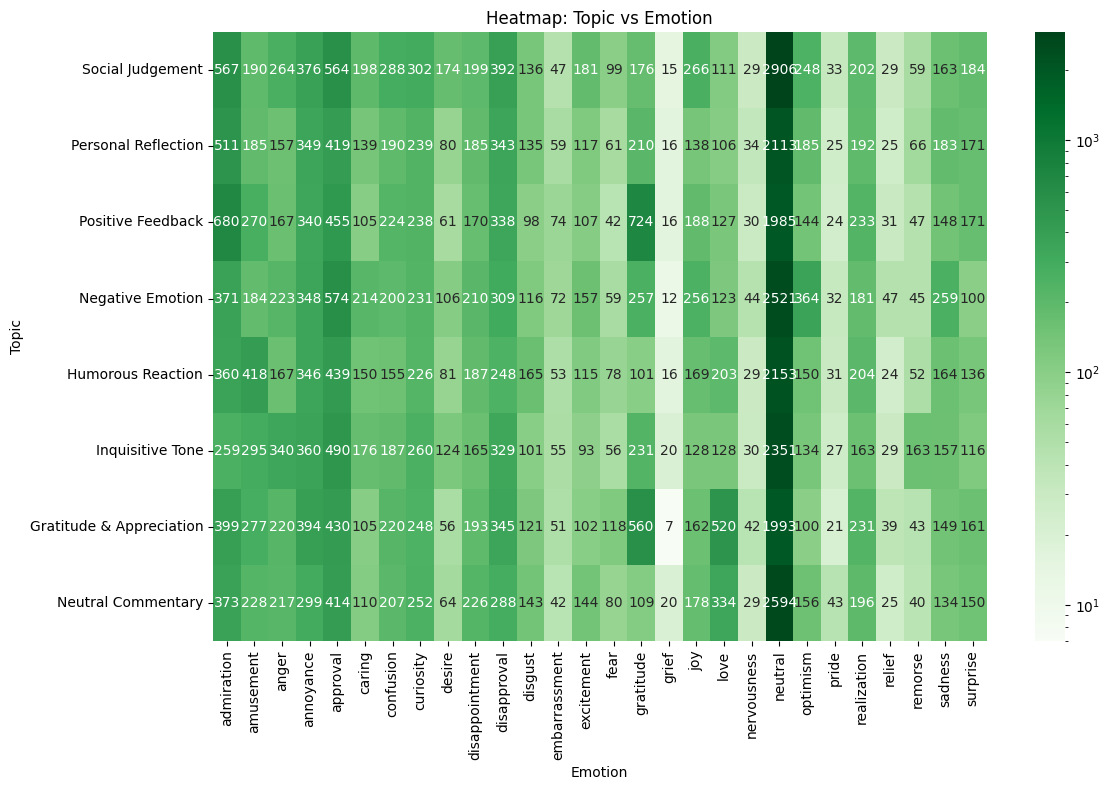

In [87]:
import seaborn as sns
from matplotlib.colors import LogNorm

plt.figure(figsize=(12,8))
sns.heatmap(topic_emotion_ct, annot=True, fmt='d', cmap='Greens', norm=LogNorm())
plt.title('Heatmap: Topic vs Emotion')
plt.ylabel('Topic')
plt.xlabel('Emotion')
plt.tight_layout()
plt.show()

### 🧐 **What Do We Learn?**
Our topic modeling and emotion linkage analyses reveal that algorithms distill the rich variety of human affect into a handful of broad, high-frequency themes.
* The word clouds underscore how models prioritize generic sentiment cues—common words like "feel," "just," or "bad"—while nuanced expressions of pride, remorse, or subtle irony fade into the background.
* The heatmap further shows that each computationally derived topic aligns predominantly with just one or two emotion labels, a stark contrast to the diverse spectrum of feelings present in the raw text.

## **Sample 100 Comments to Analyze**

In [88]:
shared_sample_df = single_emotion_df.sample(n=100, random_state=42)

## **Compare Emotion Predictions: GPT-4’s Zero-Shot Classification vs. GoEmotions "Ground Truth" Labels**

GPT-4 (Zero-Shot) is a large language model prompted to classify text into one of the 28 GoEmotions emotion labels without any fine-tuning. Unlike BERT (Savani), it was not trained on the GoEmotions dataset and instead relies on its general world knowledge and linguistic understanding.

GPT-4 is given each text and asked to choose the most appropriate label from the GoEmotions taxonomy. This setup tests GPT-4’s ability to generalize to fine-grained emotional categories in a zero-shot setting.



### **Create a GPT-4 Prompt Function**

In [89]:
from openai import OpenAI
import os
from getpass import getpass
from google.colab import userdata

# Get secret from Colab

api_key = userdata.get('OpenAi')
os.environ["OPENAI_API_KEY"] = api_key

# Initialize client
client = OpenAI()


emotion_list = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism',
    'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise',
    'neutral'
]


def get_gpt4_emotion(text, emotion_list):
    prompt = (
        f"Text: {text}\n"
        f"What is the most likely emotion from this list: {', '.join(emotion_list)}?\n"
        "Answer with one word only."
    )

    response = client.chat.completions.create(
        model="gpt-4",
        messages=[
            {"role": "system", "content": "You are an emotion classification assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip().lower()

### **Run GPT-4 Predictions**


In [90]:
gpt4_df = shared_sample_df.copy()

# Get the ground truth label (the one column with 1)
gpt4_df['GoEmotions'] = gpt4_df[emotion_list].idxmax(axis=1)

# Use GPT-4 to predict the label
gpt4_df['GPT-4'] = gpt4_df['text'].apply(lambda x: get_gpt4_emotion(x, emotion_list))

# Display the comparison
display(gpt4_df[['text', 'GoEmotions', 'GPT-4']])


,text,GoEmotions,GPT-4
69706,The cutest.,admiration,admiration
16854,He’s Russian you forgot that.,annoyance,neutral
3772,Do not defend yourself.,neutral,disapproval
18955,tRuLy A wOrK oF wOnDeR,surprise,admiration
40622,It's when you rock back and forth like an autist or do other repetitive movements because it feels natural to do so.,approval,neutral
27075,"If you're going to troll us, at least put a little effort into it.",optimism,annoyance
40476,We are not making the lead of our big budget action movie half dog!,relief,annoyance
12278,"Just being impatient here before the execution information page updates, but if anyone's bought it could you tell me how much health [NAME] new execution gives?",curiosity,curiosity
59044,You can always kneel.,approval,neutral
68242,Eastern European here. Very cool! We’re really all the same.,admiration,approval


### **Confusion Matrix: GPT-4 vs. GoEmotions**



Text(0.5, 1.0, 'GPT-4 vs. GoEmotions Confusion Matrix')

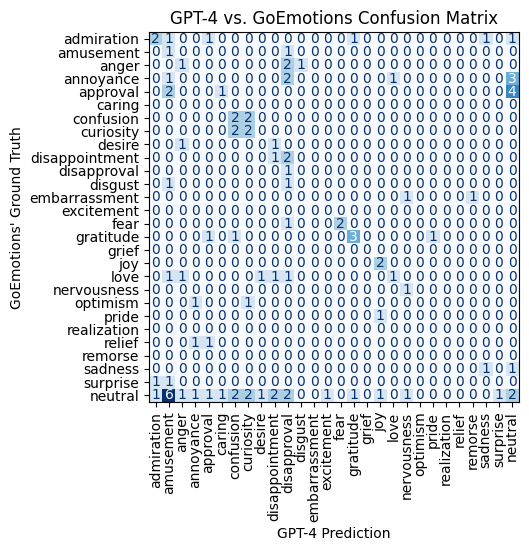

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gpt4_goemo_df = pd.DataFrame({
    'text': gpt4_df['text'],
    'GoEmotions': gpt4_df['GoEmotions'],
    'GPT-4': gpt4_df['GPT-4'],
})

gpt4_goemo_df['gpt4_agrees'] = gpt4_goemo_df['GPT-4'] == gpt4_goemo_df['GoEmotions']

gpt4_goemo_cm = confusion_matrix(
    gpt4_goemo_df['GoEmotions'],
    gpt4_goemo_df['GPT-4'],
    labels=emotion_list  # all 28 GoEmotions labels
)

gpt4_disp = ConfusionMatrixDisplay(confusion_matrix=gpt4_goemo_cm , display_labels=emotion_list)

gpt4_disp.plot(
    xticks_rotation='vertical',
    cmap='Blues',
    values_format='d',
    colorbar=False
)
plt.xlabel("GPT-4 Prediction")
plt.ylabel("GoEmotions' Ground Truth")
plt.title("GPT-4 vs. GoEmotions Confusion Matrix")


In [92]:
gpt4_confusion_pairs = gpt4_goemo_df[gpt4_goemo_df['GPT-4'] != gpt4_goemo_df['GoEmotions']]
gpt4_confusion_counts = gpt4_confusion_pairs.groupby(['GoEmotions', 'GPT-4']).size().sort_values(ascending=False)
print(gpt4_confusion_counts.head(10))

GoEmotions      GPT-4      
neutral         amusement      6
approval        neutral        4
annoyance       neutral        3
approval        amusement      2
disappointment  disapproval    2
confusion       curiosity      2
anger           disapproval    2
annoyance       disapproval    2
neutral         confusion      2
curiosity       confusion      2
dtype: int64


### **Confusion Matrix: GPT-4 vs. GoEmotions Results**

The confusion matrix reveals GPT-4's tendency to default to "neutral" or overgeneralize emotional categories, particularly for rarer or more nuanced emotions. Misclassifications are common among semantically close emotions. This supports the critique that algorithms often flatten emotional complexity into a narrower expressive range.

<br>

**1. GPT-4 tends to over-predict "neutral"**:
  * GPT-4's tendency to default to "**neutral**" or **overgeneralize** emotional categories, particularly for rarer or more nuanced emotions like **remorse** or **realization**. This reflects the reduction of emotional nuance.

**2. Closely related emotions get confused**:
* Misclassifications are common among semantically close emotions - **confusion** vs. **curiosity**, **gratitude** vs. **approval** - reflecting GPT-4’s limitations in detangling semantically and emotionally adjacent categories. Even with fine-grained labels, the model's emotional space is blurrier than the annotation scheme.

**3. Rare emotions are barely predicted**:
* Rare emotions are barely predicted. Some rows have almost no correct predictions: **embarrassment**, **nervousness**, **realization**, **remorse**, **relief** all have zeros or near-zeros.

**4. Strong performance on common categories**:
* **joy**, **amusement**, **neutral**, **approval**, **confusion**
* GPT-4 performs best on more frequent or clearly defined emotions, which likely have stronger lexical signals or more training examples.


## **Compare Emotion Predictions: BERT (Savani) vs. GoEmotions "Ground Truth" Labels**

The BERT (Savani) model is a version of BERT-base that has been fine-tuned on the GoEmotions dataset by Hugging Face contributor Bhadresh Savani. It was trained to classify Reddit comments into one of the 28 GoEmotions emotion labels.

Unlike general-purpose BERT models trained only on large corpora like Wikipedia and BooksCorpus, this version has been specifically adapted to understand fine-grained emotional nuance in text. It outputs a single predicted emotion label for each input, using the softmax of classification logits.



In [93]:
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Get HF token
hf_token = userdata.get("HuggingFace")
login(token=hf_token)

# Load BERT model fine-tuned on GoEmotions
model_name = "bhadresh-savani/bert-base-go-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

# Load label mapping
id2label = model.config.id2label

def get_bert_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        return id2label[pred_idx].lower()

bert_sample_df = shared_sample_df.copy()

# Get the ground truth label
bert_sample_df['GoEmotions'] = bert_sample_df[emotion_list].idxmax(axis=1)

# Predict with BERT
bert_sample_df['BERT (Savani)'] = bert_sample_df['text'].apply(get_bert_emotion)

# Show comparison
display(bert_sample_df[['text', 'GoEmotions', 'BERT (Savani)']])

,text,GoEmotions,BERT (Savani)
69706,The cutest.,admiration,admiration
16854,He’s Russian you forgot that.,annoyance,neutral
3772,Do not defend yourself.,neutral,neutral
18955,tRuLy A wOrK oF wOnDeR,surprise,surprise
40622,It's when you rock back and forth like an autist or do other repetitive movements because it feels natural to do so.,approval,approval
27075,"If you're going to troll us, at least put a little effort into it.",optimism,neutral
40476,We are not making the lead of our big budget action movie half dog!,relief,neutral
12278,"Just being impatient here before the execution information page updates, but if anyone's bought it could you tell me how much health [NAME] new execution gives?",curiosity,curiosity
59044,You can always kneel.,approval,neutral
68242,Eastern European here. Very cool! We’re really all the same.,admiration,admiration


### **Confusion Matrix: BERT (Savani) vs. GoEmotions**

Text(0.5, 1.0, 'BERT (Savani) vs. GoEmotions Confusion Matrix')

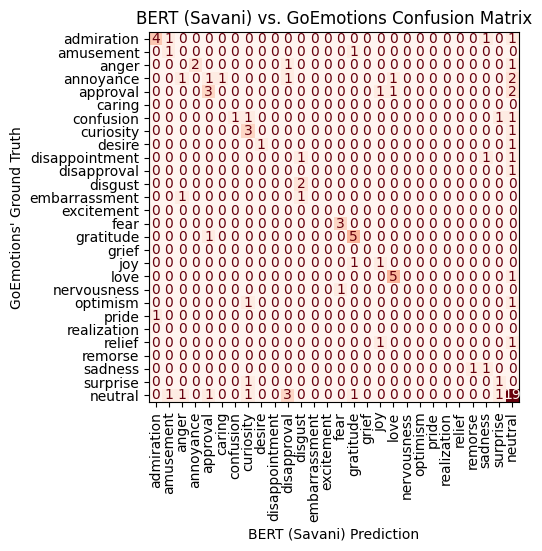

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
bert_cm = confusion_matrix(
    bert_sample_df['GoEmotions'],
    bert_sample_df['BERT (Savani)'],
    labels=emotion_list  # ensure all emotions are included in fixed order
)

# Plot the confusion matrix
bert_disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_cm,
    display_labels=emotion_list
)

bert_disp.plot(
    xticks_rotation='vertical',
    cmap='Reds',
    values_format='d',
    colorbar=False
)

plt.xlabel("BERT (Savani) Prediction")
plt.ylabel("GoEmotions' Ground Truth")
plt.title("BERT (Savani) vs. GoEmotions Confusion Matrix")


In [95]:
# Rows where BERT disagrees with ground truth
bert_confusion_pairs = bert_sample_df[bert_sample_df['BERT (Savani)'] != bert_sample_df['GoEmotions']]

# Group and count the confusion pairs
bert_confusion_counts = bert_confusion_pairs.groupby(['GoEmotions', 'BERT (Savani)']).size().sort_values(ascending=False)

# Display the top 10 most common misclassifications
print(bert_confusion_counts.head(10))

GoEmotions  BERT (Savani)
neutral     disapproval      3
annoyance   neutral          2
anger       annoyance        2
approval    neutral          2
admiration  amusement        1
amusement   gratitude        1
anger       disapproval      1
annoyance   anger            1
anger       neutral          1
annoyance   approval         1
dtype: int64


### **Confusion Matrix: BERT (Savani) vs. GoEmotions Results**

The matrix shows many predictions falling on the diagonal, meaning BERT (Savani) often agrees with GoEmotions labels,  especially for high-frequency classes like neutral, approval, and amusement. Low off-diagonal density means misclassifications are sparse and usually between semantically adjacent emotions.

<br>

1. **Frequent misclassification of neutral**:
  * BERT (Savani) tends to both overpredict and underpredict **neutral**.

2. **Closely related emotions get confused**:
  * Misclassifications are common among semantically close emotions - **anger** vs. **annoyance**, **admiration** vs. **amusement**, or **approval ** vs. **neutral** - are the ones most frequently confused.
  * BERT does not fully separate subtle emotion categories, even when trained specifically on GoEmotions.

3. **BERT shows asymmetry in some confusions**:
  * For example, BERT predicts **disapproval** when the true label is **neutral**, but not necessarily the reverse.
  * This may reflect a **bias toward negative judgment** when sentiment is ambiguous.

4. **Rare emotions are barely predicted**:
  * Some emotions like **pride**, **relief**, **grief** barely appear in misclassifications, possibly due to low overall frequency in the sample.



## **Compare Emotion Predictions: GoEmotions "Ground Truth" vs. BERT (Savani) vs. GPT-4:**

In [96]:
# Merge df's to compare GoEmotions, BERT (Savani), GPT-4
comparison_df = pd.merge(
    gpt4_goemo_df[['text', 'GoEmotions', 'GPT-4']],
    bert_sample_df[['text', 'BERT (Savani)']],
    on='text'
)

display(comparison_df[['text', 'GoEmotions', 'BERT (Savani)', 'GPT-4']])


,text,GoEmotions,BERT (Savani),GPT-4
0,The cutest.,admiration,admiration,admiration
1,He’s Russian you forgot that.,annoyance,neutral,neutral
2,Do not defend yourself.,neutral,neutral,disapproval
3,tRuLy A wOrK oF wOnDeR,surprise,surprise,admiration
4,It's when you rock back and forth like an autist or do other repetitive movements because it feels natural to do so.,approval,approval,neutral
5,"If you're going to troll us, at least put a little effort into it.",optimism,neutral,annoyance
6,We are not making the lead of our big budget action movie half dog!,relief,neutral,annoyance
7,"Just being impatient here before the execution information page updates, but if anyone's bought it could you tell me how much health [NAME] new execution gives?",curiosity,curiosity,curiosity
8,You can always kneel.,approval,neutral,neutral
9,Eastern European here. Very cool! We’re really all the same.,admiration,admiration,approval


### **Count Predictions from GoEmotions, GPT-4, BERT (Savani)**

In [97]:
# Count frequencies and reindex to include all 28 emotions
goemotions_counts = comparison_df['GoEmotions'].value_counts().reindex(emotion_list, fill_value=0)
bert_counts = comparison_df['BERT (Savani)'].value_counts().reindex(emotion_list, fill_value=0)
gpt4_counts = comparison_df['GPT-4'].value_counts().reindex(emotion_list, fill_value=0)

# Combine into one DataFrame
emotion_distribution_df = pd.DataFrame({
    'GoEmotions (Ground Truth)': goemotions_counts,
    'BERT (Savani)': bert_counts,
    'GPT-4': gpt4_counts
}).astype(int)

# Display the table
display(emotion_distribution_df)


,GoEmotions (Ground Truth),BERT (Savani),GPT-4
admiration,7,5,4
amusement,2,3,14
anger,4,3,4
annoyance,7,2,3
approval,7,6,4
caring,0,1,2
confusion,4,1,7
curiosity,4,7,7
desire,2,1,2
disappointment,3,0,5


### **Plot the Distributions (to Show Reduction/Flattening)**

### 🟦 **GoEmotions - "Ground Truth"**

*   Labels are relatively well-distributed, with less skew toward any single emotion.

*   While ***neutral*** is still frequent, many fine-grained emotions like ***admiration***, ***approval***, ***joy***, and ***gratitude*** appear with decent frequency, indicating rich annotation.


### 🟧 **BERT (Savani)**
* Heavily favors ***neutral***, far more than the ground truth.

* Shows signs of emotional flattening, assigning fewer distinct emotion labels.

* Emotions like ***curiosity***, ***confusion***, ***desire***, or ***nervousness*** are nearly absent or very underrepresented.

### 🟩 **GPT-4**
* More balanced than BERT, with greater coverage across rare emotions like ***disgust***, ***amusement***, ***disapproval***, ***confusion***, etc.

* Still less faithful than the ground truth, but shows higher sensitivity to emotional nuance than BERT.

### **Overall Insights**:
* Both models reduce emotional diversity, but GPT-4 preserves nuance better than BERT (Savani).

* The overprediction of ***neutral*** reflects how models often play it safe or fail to decode emotional cues when uncertain.

* This visualization directly supports the claim that algorithms flatten emotion, *especially in single-label classification setups*.



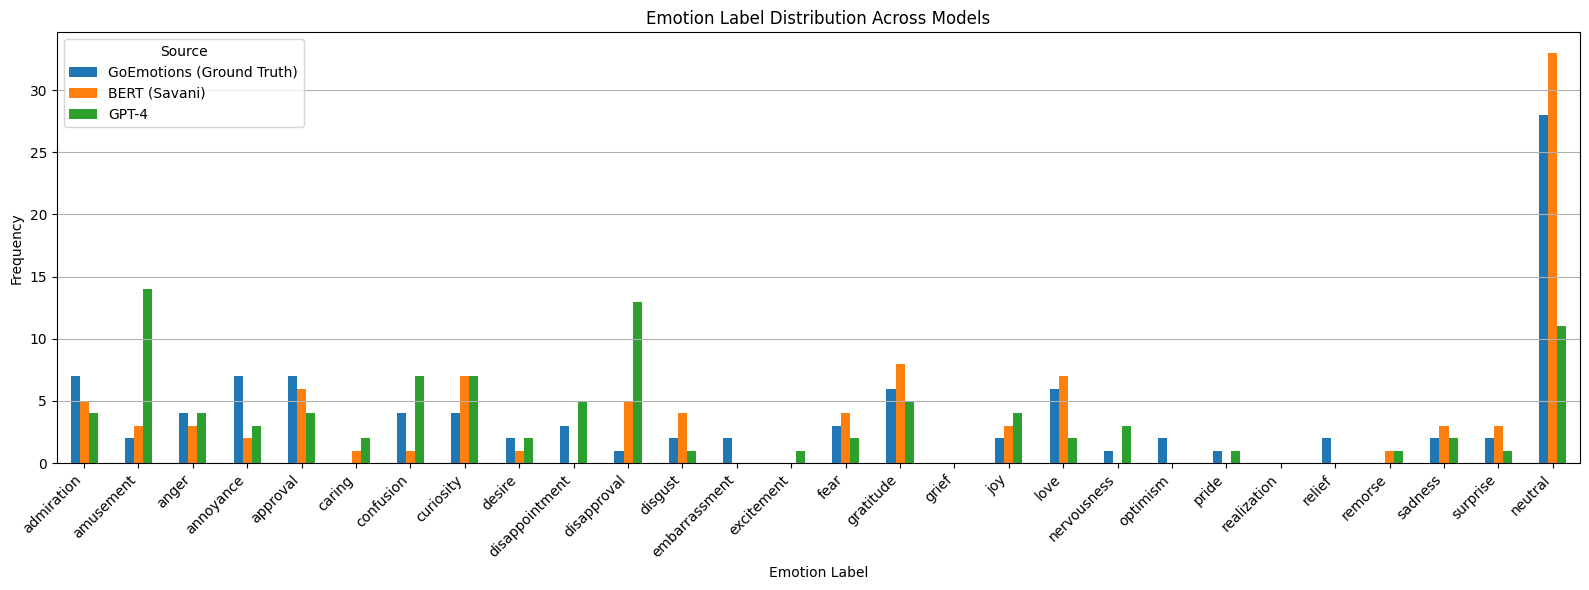

In [98]:
import matplotlib.pyplot as plt

emotion_distribution_df.plot(kind='bar', figsize=(16, 6))
plt.title("Emotion Label Distribution Across Models")
plt.xlabel("Emotion Label")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title="Source")
plt.tight_layout()
plt.show()


### **Alluvial Flow: GoEmotions → BERT (Savani) → GPT-4**

### How To Read It:

1. **Left Column: GoEmotions Ground Truth Labels**
  * These are human annotations from the GoEmotions dataset.

  * Each colored box is an emotion category (e.g., neutral, gratitude, approval).

  * Each line starts from here.


2. **Middle Column: BERT (Savani) Predictions**
  * These are the emotion predictions made by the fine-tuned BERT model.

  * **Lines that bend** = BERT disagreed with the human label.

  * **Straight lines** = BERT matched the GoEmotions label.

3. **Right Column: GPT-4 Predictions**
  * These are zero-shot predictions by GPT-4 on the same texts.

  * A line from BERT to GPT-4 shows whether the two models agreed.

  * Lines that bend again mean GPT-4 disagreed with BERT, and possibly also with GoEmotions.



In [99]:
import plotly.graph_objects as go
import numpy as np

# Ensure all relevant columns exist in comparison_df
comparison_df = comparison_df[['GoEmotions', 'BERT (Savani)', 'GPT-4']].copy()

# Dynamically build the full list of unique emotions from all columns
emotion_list = sorted(set(
    comparison_df['GoEmotions'].dropna().unique().tolist() +
    comparison_df['BERT (Savani)'].dropna().unique().tolist() +
    comparison_df['GPT-4'].dropna().unique().tolist()
))

# Ensure all values are treated as categories using updated emotion_list
for col in ['GoEmotions', 'BERT (Savani)', 'GPT-4']:
    comparison_df[col] = pd.Categorical(comparison_df[col], categories=emotion_list)

# Group and count flows (including zero-counts where needed)
flow_counts = comparison_df.groupby(
    ['GoEmotions', 'BERT (Savani)', 'GPT-4'], observed=False
).size().reset_index(name='count')

# Create full label list across 3 stages
go_labels = emotion_list
bert_labels = emotion_list
gpt_labels = emotion_list

all_labels = go_labels + bert_labels + gpt_labels
label_to_index = {label: i for i, label in enumerate(all_labels)}

# Create links for GoEmotions → BERT and BERT → GPT
source_go_to_bert = flow_counts['GoEmotions'].map(label_to_index)
target_go_to_bert = flow_counts['BERT (Savani)'].map(lambda x: label_to_index[x] + len(go_labels))

source_bert_to_gpt = flow_counts['BERT (Savani)'].map(lambda x: label_to_index[x] + len(go_labels))
target_bert_to_gpt = flow_counts['GPT-4'].map(lambda x: label_to_index[x] + len(go_labels) + len(bert_labels))

# Combine link sources, targets, and values
sources = pd.concat([source_go_to_bert, source_bert_to_gpt]).reset_index(drop=True)
targets = pd.concat([target_go_to_bert, target_bert_to_gpt]).reset_index(drop=True)
values = pd.concat([flow_counts['count'], flow_counts['count']]).reset_index(drop=True)

# Assign consistent colors per GoEmotions source (stage 1 label)
unique_sources = flow_counts['GoEmotions'].unique().tolist()
np.random.seed(42)
source_colors = {
    emotion: "rgba({},{},{},0.5)".format(
        np.random.randint(50, 200),
        np.random.randint(50, 200),
        np.random.randint(50, 200)
    )
    for emotion in unique_sources
}

# Assign colors to all links: use the GoEmotions stage for color assignment
colors = []
for i in range(len(flow_counts)):
    emo = flow_counts.iloc[i]['GoEmotions']
    colors.append(source_colors.get(emo, 'rgba(200,200,200,0.4)'))  # for Go→BERT
for i in range(len(flow_counts)):
    emo = flow_counts.iloc[i]['GoEmotions']
    colors.append(source_colors.get(emo, 'rgba(200,200,200,0.4)'))  # same for BERT→GPT

# Create custom hover labels — first half: GoEmotions → BERT, second half: BERT → GPT
customdata = []
for i in range(len(flow_counts)):
    go_label = flow_counts.iloc[i]['GoEmotions']
    bert_label = flow_counts.iloc[i]['BERT (Savani)']
    count = flow_counts.iloc[i]['count']
    customdata.append(f"Source: {go_label}<br>Target: {bert_label}<br>Count: {count}")

for i in range(len(flow_counts)):
    bert_label = flow_counts.iloc[i]['BERT (Savani)']
    gpt_label = flow_counts.iloc[i]['GPT-4']
    count = flow_counts.iloc[i]['count']
    customdata.append(f"Source: {bert_label}<br>Target: {gpt_label}<br>Count: {count}")

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=all_labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors,
        customdata=customdata,
        hovertemplate="%{customdata}<extra></extra>"
    )
)])

fig.update_layout(
    title_text="Alluvial Flow: GoEmotions → BERT (Savani) → GPT-4",
    font_size=10
)
fig.show()

### **Some Insights:**

**1. Model Agreement vs. Ground Truth**
  * Lines that stay straight from left → middle → right mean all three agree. These are rare.

  * Lines that start at one label and branch out show disagreement, often in semantically close categories like **approval**, **gratitude**, **amusement**, or **neutral**.

**2. Emotion Flattening**
  * Thick flows into **neutral** or **approval** from many diverse GoEmotions labels suggest that both BERT and GPT-4 collapse emotional nuance into simpler or safer choices.

**3. Disagreement Patterns**
  * You can visually spot which emotions are most frequently misinterpreted or translated inconsistently across models:
    * A chunk of **gratitude** gets reclassified into **neutral** or **approval**

### **Label Entropy Across Models**

**Label Entropy**: a measure of how diverse or concentrated the predicted emotion labels are, for each source


In [100]:
import pandas as pd
from scipy.stats import entropy


# Count label frequencies
goemotions_counts = comparison_df['GoEmotions'].value_counts(normalize=True)
bert_counts = comparison_df['BERT (Savani)'].value_counts(normalize=True)
gpt4_counts = comparison_df['GPT-4'].value_counts(normalize=True)

# Align indexes to compute entropy on same label space
all_labels = sorted(set(goemotions_counts.index) | set(bert_counts.index) | set(gpt4_counts.index))
goemotions_probs = goemotions_counts.reindex(all_labels, fill_value=0)
bert_probs = bert_counts.reindex(all_labels, fill_value=0)
gpt4_probs = gpt4_counts.reindex(all_labels, fill_value=0)

# Compute entropy
goemotions_entropy = entropy(goemotions_probs, base=2)
bert_entropy = entropy(bert_probs, base=2)
gpt4_entropy = entropy(gpt4_probs, base=2)

# Prepare output
entropy_df = pd.DataFrame({
    'Model': ['GoEmotions (Ground Truth)', 'BERT (Savani)', 'GPT-4'],
    'Label Entropy (bits)': [goemotions_entropy, bert_entropy, gpt4_entropy]
})

entropy_df

,Model,Label Entropy (bits)
0,GoEmotions (Ground Truth),3.882959
1,BERT (Savani),3.541142
2,GPT-4,4.108912


| Model                     | Label Entropy (bits) | Interpretation                                                                 |
|--------------------------|----------------------|---------------------------------------------------------------------------------|
| GoEmotions (Ground Truth)| 3.88                 | Balanced diversity; reflects human annotation nuance.                          |
| BERT (Savani)            | 3.54                 | Lowest entropy; likely overuses common labels like *neutral*.                  |
| GPT-4                    | 4.11                 | Highest entropy; uses a broader range of emotions, possibly overgeneralizing.  |



**Interpretation:**

- **Higher entropy** = more diverse emotion predictions.
- **Lower entropy** = more concentrated predictions on fewer categories.

**What this suggests:**

- **BERT (Savani)** shows the *lowest entropy* (3.54), suggesting it overuses common labels like `neutral`, reducing emotional nuance.
- **GPT-4** shows the *highest entropy* (4.01), producing a wider spread of emotion predictions than even the original human annotations.
- The **GoEmotions ground truth** lies in the middle (3.88), indicating a balanced but not overly diffuse emotional taxonomy.


These results suggest that **BERT tends to collapse emotional complexity**, while **GPT-4 might overextend into finer categories**, aligning with our thesis that models “read and reduce” emotional expression in divergent ways.


## **Conclusions**



Our analysis shows that both **fine-tuned (BERT Savani)** and **general-purpose (GPT-4)** models struggle to fully capture the nuance of human emotional expression. While BERT aligns more closely with GoEmotions labels, thanks to task-specific training, it still flattens complex affect, especially when emotions are subtle or context-dependent.

GPT-4, despite operating zero-shot, performs comparably in many cases, but frequently overuses broad categories like neutral, amusement, or disapproval, reflecting its more generalized training.

<br>

**Confusion matrices** revealed frequent misclassifications between semantically close labels, like ***annoyance*** vs. ***disapproval***, especially for GPT-4.

**Alluvial flow diagrams** showed how emotion labels shift from ground truth to model outputs, illustrating where interpretive drift occurs.

**Label entropy** analysis highlighted that both models often assign high confidence to incorrect predictions, signaling overconfidence.

**Multi-label vs. single-label** showed just how often emotions in real-world text are messy or unclear, something models still struggle to deal with.

**Topic-emotion heatmaps** revealed emotion clusters by theme, but also reinforced that models tend to default to dominant emotions within a topic.

<br>

Ultimately, even with access to rich training data, current models reduce emotion to discrete, simplified categories—masking ambiguity, suppressing subtlety, and failing to reflect the layered way humans feel and express.